In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier



In [4]:
df = pd.read_csv("train_transaction.csv")

features = [
    "TransactionAmt",
    "TransactionDT",
    "card1",
    "C1",
    "C2",
    "C3",
    "C4",
    "C5",
    "C6",
    "C7"
]

X = df[features]
y = df["isFraud"]

In [5]:
df.shape

(590540, 394)

In [6]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
V335              508189
V336              508189
V337              508189
V338              508189
V339              508189
Length: 394, dtype: int64

In [8]:
X = X.fillna(X.median())


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [10]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)


In [12]:
print("After SMOTE:")
print(y_train.value_counts())

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)



After SMOTE:
isFraud
0    455902
1    455902
Name: count, dtype: int64


In [ ]:
model.fit(X_train, y_train)

probabilities = model.predict_proba(X_test)[:, 1]

threshold = 0.30

predictions = (probabilities >= threshold).astype(int)



ROC-AUC Score:
0.8154

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93    113975
           1       0.15      0.55      0.23      4133

    accuracy                           0.87    118108
   macro avg       0.56      0.72      0.58    118108
weighted avg       0.95      0.87      0.91    118108


Feature Importance:
C4                0.346790
C1                0.142110
C7                0.132045
C5                0.107693
C6                0.089916
C2                0.086683
TransactionAmt    0.053481
TransactionDT     0.017247
card1             0.016470
C3                0.007565
dtype: float32


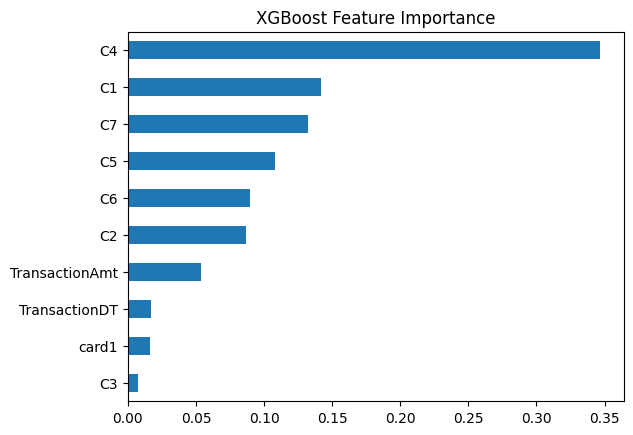

In [15]:
print("\nROC-AUC Score:")
print(round(roc_auc_score(y_test, probabilities), 4))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

importance = pd.Series(
    model.feature_importances_,
    index=features
)

print("\nFeature Importance:")
print(importance.sort_values(ascending=False))

importance.sort_values().plot(
    kind="barh",
    title="XGBoost Feature Importance"
)

plt.show()